# Notebook 02: Phase 1 — Market Clustering

## Purpose
Use K-means clustering to identify which prediction markets are structurally
attractive targets for insider trading, without being told which markets were
actually targeted.

## Hypothesis
Markets with high uncertainty at open, high volume, and short time to resolution
are more attractive to informed traders. K-means clustering should group these
markets together without prior knowledge of which ones were known insider targets.

## Validation
Known insider-targeted markets (Maduro capture, US/Israel strikes on Iran,
Google Year in Search / d4vd, State of the Union attendance, George Santos)
are checked against cluster assignments after the blind run. If the hypothesis
holds, they should concentrate in the cluster with the highest structural
attractiveness profile.

## Features
- `uncertainty`: how close to 50/50 the market was at open (derived from `opening_price`)
- `log_volume`: log-transformed total trading volume
- `time_to_resolution_hrs`: market duration in hours

## Inputs
- `data/raw/markets_polymarket.parquet` — 9,521 Polymarket markets with metadata and opening price

## Outputs
- `data/processed/features_stage1.parquet` — one row per market with engineered features
- `data/processed/cluster_assignments.parquet` — cluster label per market
- `outputs/clusters_pca.png` — PCA visualization of clusters

In [1]:
# Cell 2 — Imports and setup
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

Path("../data/processed").mkdir(parents=True, exist_ok=True)
Path("../outputs").mkdir(parents=True, exist_ok=True)

print("Ready.")

Ready.


In [2]:
# Cell 3 — Load data and engineer features

df = pd.read_parquet("../data/raw/markets_polymarket.parquet")

# Parse dates
df["closed_time"] = pd.to_datetime(df["closed_time"], utc=True, errors="coerce")
df["start_date"] = pd.to_datetime(df["start_date"], utc=True, errors="coerce")

# Feature: uncertainty — how close to 50/50 at open
# opening_price of 0.5 = maximum uncertainty (score of 1.0)
# opening_price of 0.0 or 1.0 = no uncertainty (score of 0.0)
df["uncertainty"] = 1 - abs(df["opening_price"] - 0.5) * 2

# Feature: log-transformed volume
df["log_volume"] = np.log1p(df["volume"].fillna(0))

# Feature: time to resolution in hours
df["time_to_resolution_hrs"] = (
    df["closed_time"] - df["start_date"]
).dt.total_seconds() / 3600

# Drop rows missing any feature
features = df.dropna(subset=["uncertainty", "log_volume", "time_to_resolution_hrs"]).copy()

# Save
features.to_parquet("../data/processed/features_stage1.parquet", index=False)

print(f"Markets after feature engineering: {len(features)}")
print(features[["uncertainty", "log_volume", "time_to_resolution_hrs"]].describe().round(3))

Markets after feature engineering: 0
       uncertainty  log_volume  time_to_resolution_hrs
count          0.0         0.0                     0.0
mean           NaN         NaN                     NaN
std            NaN         NaN                     NaN
min            NaN         NaN                     NaN
25%            NaN         NaN                     NaN
50%            NaN         NaN                     NaN
75%            NaN         NaN                     NaN
max            NaN         NaN                     NaN


In [4]:
df = pd.read_parquet("../data/raw/markets_polymarket.parquet")
print(df.columns.tolist())
print(df.dtypes)
print(df.head(3).to_string())

['market_id', 'event_id', 'question', 'category', 'start_date', 'end_date', 'closed_time', 'volume', 'liquidity', 'enable_order_book', 'token_ids', 'platform', 'opening_price']
market_id                         object
event_id                          object
question                          object
category                          object
start_date           datetime64[ns, UTC]
end_date             datetime64[ns, UTC]
closed_time          datetime64[ns, UTC]
volume                           float64
liquidity                        float64
enable_order_book                   bool
token_ids                         object
platform                          object
opening_price                    float64
dtype: object
                                                            market_id event_id                                                             question   category start_date                  end_date               closed_time        volume  liquidity  enable_order_book           

In [3]:
# Cell 4 — Compute Stage 1 features for Kalshi markets
def compute_kalshi_features(markets, prices):
    features = []
    for _, market in markets.iterrows():
        market_id = market["market_id"]
        mprices = prices[prices["market_id"] == market_id].sort_values("timestamp")

        if len(mprices) < 5:
            continue

        # Use price_close as the canonical price series
        price_series = mprices["price_close"].dropna()

        if len(price_series) < 5:
            continue

        opening_price = price_series.iloc[0]
        uncertainty = 1 - abs(opening_price - 0.5) * 2
        price_volatility = price_series.std()
        price_range = price_series.max() - price_series.min()
        drift = price_series.iloc[-1] - price_series.iloc[0]

        if pd.notna(market["start_date"]) and pd.notna(market["end_date"]):
            time_to_resolution_hrs = (
                market["end_date"] - market["start_date"]
            ).total_seconds() / 3600
        else:
            time_to_resolution_hrs = (
                mprices["timestamp"].max() - mprices["timestamp"].min()
            ).total_seconds() / 3600

        if pd.notna(market["end_date"]):
            pre_window = mprices[
                mprices["timestamp"] >= market["end_date"] - pd.Timedelta(hours=48)
            ]
        else:
            pre_window = mprices.tail(48)

        price_col = pre_window["price_close"].dropna()
        pre_velocity = abs(price_col.diff()).mean() if len(price_col) > 1 else 0

        features.append({
            "market_id": market_id,
            "question": market.get("question"),
            "category": market.get("category"),
            "platform": "kalshi",
            "volume": market.get("volume"),
            "opening_price": opening_price,
            "uncertainty": uncertainty,
            "price_volatility": price_volatility,
            "price_range": price_range,
            "time_to_resolution_hrs": time_to_resolution_hrs,
            "drift": drift,
            "pre_resolution_velocity": pre_velocity,
            "n_price_points": len(mprices),
        })

    return pd.DataFrame(features)

kalshi_features = compute_kalshi_features(kalshi_markets, kalshi_prices)
print(f"Kalshi features: {len(kalshi_features)} markets, {len(kalshi_features.columns)} features")
kalshi_features.head()

Kalshi features: 164 markets, 13 features


,market_id,question,category,platform,volume,opening_price,uncertainty,price_volatility,price_range,time_to_resolution_hrs,drift,pre_resolution_velocity,n_price_points
0,KXFED-26MAR-T5.00,Will the upper bound of the federal funds rate...,KXFED-26MAR,kalshi,1880.0,0.15,0.30,3.055050e-02,0.14,5380.21923,-0.14,0.0,3715
1,KXFED-26MAR-T4.50,Will the upper bound of the federal funds rate...,KXFED-26MAR,kalshi,10659.0,0.07,0.14,1.095445e-02,0.06,5380.21923,-0.06,0.0,3683
2,KXFED-26MAR-T4.25,Will the upper bound of the federal funds rate...,KXFED-26MAR,kalshi,22014.0,0.01,0.02,3.503970e-18,0.00,5380.21923,0.00,0.0,3431
3,KXFED-26MAR-T4.00,Will the upper bound of the federal funds rate...,KXFED-26MAR,kalshi,149225.0,0.23,0.46,5.939895e-02,0.22,5380.21923,-0.21,0.0,3692
4,KXFED-26MAR-T3.75,Will the upper bound of the federal funds rate...,KXFED-26MAR,kalshi,930486.0,0.42,0.84,4.456369e-02,0.41,5380.21923,-0.41,0.0,4181


In [4]:
# Cell 5 — Combine and clean features
features = pd.concat([pm_features, kalshi_features], ignore_index=True)

# Convert numeric columns
for col in ["volume", "opening_price", "uncertainty", "price_volatility",
            "price_range", "time_to_resolution_hrs", "drift", "pre_resolution_velocity"]:
    features[col] = pd.to_numeric(features[col], errors="coerce")

# Drop rows with too many nulls
features = features.dropna(subset=["opening_price", "price_volatility", "time_to_resolution_hrs"]).copy()

# Cap extreme outliers in time_to_resolution (some markets span years)
features["time_to_resolution_hrs"] = features["time_to_resolution_hrs"].clip(0, 8760)  # max 1 year

# Log transform volume (heavy right skew)
features["log_volume"] = np.log1p(features["volume"].fillna(0))

features.to_parquet("../data/processed/features_stage1.parquet", index=False)
print(f"Combined features: {len(features)} markets")
print(f"\nFeature summary:")
print(features[["uncertainty", "price_volatility", "price_range",
                "time_to_resolution_hrs", "drift", "pre_resolution_velocity", "log_volume"]].describe())

Combined features: 178 markets

Feature summary:
       uncertainty  price_volatility  price_range  time_to_resolution_hrs  \
count   178.000000        178.000000   178.000000              178.000000   
mean      0.381011          0.096829     0.372576             5571.336147   
std       0.296205          0.081041     0.288728             2729.604494   
min       0.012000          0.000000     0.000000               32.992500   
25%       0.140000          0.030664     0.120000             3002.987926   
50%       0.280000          0.075816     0.315000             5418.208429   
75%       0.620000          0.141454     0.600000             8284.286493   
max       1.000000          0.354113     0.970000             8760.000000   

            drift  pre_resolution_velocity  log_volume  
count  178.000000               178.000000  178.000000  
mean     0.080413                 0.007621   11.224064  
std      0.333829                 0.032465    2.884583  
min     -0.810000            

In [5]:
# Cell 6 — Normalize features for clustering
from sklearn.preprocessing import StandardScaler

FEATURE_COLS = [
    "uncertainty",
    "price_volatility",
    "price_range",
    "time_to_resolution_hrs",
    "drift",
    "pre_resolution_velocity",
    "log_volume"
]

X = features[FEATURE_COLS].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Feature matrix shape: {X_scaled.shape}")
print(f"Features: {FEATURE_COLS}")

Feature matrix shape: (178, 7)
Features: ['uncertainty', 'price_volatility', 'price_range', 'time_to_resolution_hrs', 'drift', 'pre_resolution_velocity', 'log_volume']


Cluster sizes:
cluster
1    98
0    79
2     1
Name: count, dtype: int64

Variance explained by PCA: 54.1%


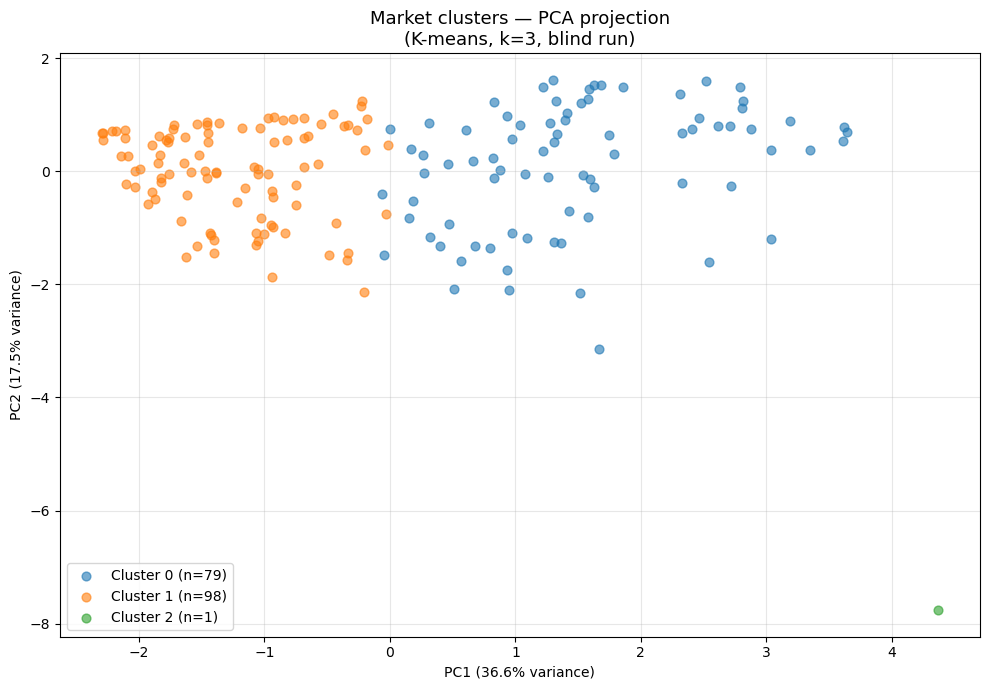

In [6]:
# Cell 7 — K-means clustering (run blind, no labels)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Run K-means with k=3 (low / medium / high attractiveness)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
features["cluster"] = kmeans.fit_predict(X_scaled)

# PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
features["pca_x"] = X_pca[:, 0]
features["pca_y"] = X_pca[:, 1]

print(f"Cluster sizes:")
print(features["cluster"].value_counts())
print(f"\nVariance explained by PCA: {pca.explained_variance_ratio_.sum():.1%}")

# Plot
fig, ax = plt.subplots(figsize=(10, 7))
colors = {0: "#1f77b4", 1: "#ff7f0e", 2: "#2ca02c"}
for cluster in [0, 1, 2]:
    mask = features["cluster"] == cluster
    ax.scatter(
        features.loc[mask, "pca_x"],
        features.loc[mask, "pca_y"],
        c=colors[cluster],
        label=f"Cluster {cluster} (n={mask.sum()})",
        alpha=0.6,
        s=40
    )

ax.set_title("Market clusters — PCA projection\n(K-means, k=3, blind run)", fontsize=13)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/clusters_pca.png", dpi=150)
plt.show()

In [7]:
# Cell 8 — Profile each cluster
cluster_profile = features.groupby("cluster")[FEATURE_COLS].mean().round(3)
print("Cluster profiles (mean feature values):")
print(cluster_profile)

print("\nCluster platform breakdown:")
print(pd.crosstab(features["cluster"], features["platform"]))

print("\nSample markets per cluster:")
for cluster in sorted(features["cluster"].unique()):
    print(f"\n--- Cluster {cluster} ---")
    sample = features[features["cluster"] == cluster].nlargest(5, "log_volume")
    print(sample[["question", "platform", "uncertainty", "price_volatility", "log_volume"]].to_string())

Cluster profiles (mean feature values):
         uncertainty  price_volatility  price_range  time_to_resolution_hrs  \
cluster                                                                       
0              0.594             0.168        0.643                5021.324   
1              0.208             0.039        0.149                6049.155   
2              0.440             0.136        0.890                2196.083   

         drift  pre_resolution_velocity  log_volume  
cluster                                              
0        0.170                    0.009      11.840  
1        0.001                    0.003      10.743  
2        0.760                    0.405       9.750  

Cluster platform breakdown:
platform  kalshi  polymarket
cluster                     
0             72           7
1             91           7
2              1           0

Sample markets per cluster:

--- Cluster 0 ---
                                                     question    platfor

In [8]:
# Cell 9 — Validate against pseudo-labels
# These are markets we know were likely targeted by insider traders
KNOWN_TARGETS = [
    "trump", "kamala", "harris", "presidential election",
    "fed decreases", "fed increases", "iran", "ceasefire",
    "maduro", "shutdown"
]

def is_known_target(question):
    if not isinstance(question, str):
        return False
    q = question.lower()
    return any(kw in q for kw in KNOWN_TARGETS)

features["is_known_target"] = features["question"].apply(is_known_target)

print(f"Known targets in dataset: {features['is_known_target'].sum()}")
print(f"\nCluster distribution of known targets:")
print(pd.crosstab(
    features["cluster"],
    features["is_known_target"],
    margins=True
))

# Which cluster contains the most known targets?
target_by_cluster = features[features["is_known_target"]].groupby("cluster").size()
print(f"\nKnown targets per cluster:")
print(target_by_cluster)
print(f"\nHighest concentration cluster: {target_by_cluster.idxmax()}")

Known targets in dataset: 12

Cluster distribution of known targets:
is_known_target  False  True  All
cluster                          
0                   73     6   79
1                   92     6   98
2                    1     0    1
All                166    12  178

Known targets per cluster:
cluster
0    6
1    6
dtype: int64

Highest concentration cluster: 0


In [9]:
# Cell 10 — Save cluster assignments and summary
features.to_parquet("../data/processed/cluster_assignments.parquet", index=False)

print("=== Phase 1 Summary ===")
print(f"Total markets clustered: {len(features)}")
print(f"Known targets identified: {features['is_known_target'].sum()}")
print(f"\nCluster profiles:")
print(cluster_profile)
print(f"\nKnown target concentration:")
for cluster in sorted(features["cluster"].unique()):
    cluster_markets = features[features["cluster"] == cluster]
    target_pct = cluster_markets["is_known_target"].mean() * 100
    print(f"  Cluster {cluster}: {target_pct:.1f}% known targets ({cluster_markets['is_known_target'].sum()}/{len(cluster_markets)})")

=== Phase 1 Summary ===
Total markets clustered: 178
Known targets identified: 12

Cluster profiles:
         uncertainty  price_volatility  price_range  time_to_resolution_hrs  \
cluster                                                                       
0              0.594             0.168        0.643                5021.324   
1              0.208             0.039        0.149                6049.155   
2              0.440             0.136        0.890                2196.083   

         drift  pre_resolution_velocity  log_volume  
cluster                                              
0        0.170                    0.009      11.840  
1        0.001                    0.003      10.743  
2        0.760                    0.405       9.750  

Known target concentration:
  Cluster 0: 7.6% known targets (6/79)
  Cluster 1: 6.1% known targets (6/98)
  Cluster 2: 0.0% known targets (0/1)
